Running with unified L = 5:
--------------------------------------------------------------------------------
Name                 | L     | n            | k/n          | d/n         
--------------------------------------------------------------------------------
[0,1,2,2]            | 5.0   | 5.0e+01      | 4.0000e-02   | 1.0000e-01  
[1,2,3,3]            | 5.0   | 3.8e+02      | 8.0000e-03   | 1.3333e-02  
[2,3,4,4]            | 5.0   | 2.5e+03      | 1.6000e-03   | 2.0000e-03  
4D TC                | 5.0   | 3.8e+03      | 1.6000e-03   | 6.6667e-03  
[0,1,2,3]            | 5.0   | 3.8e+02      | 7.2000e-02   | 1.3333e-02  
[1,2,3,4]            | 5.0   | 3.8e+03      | 1.4400e-02   | 1.3333e-03  
[0,1,2,4]            | 5.0   | 2.5e+03      | 9.7600e-02   | 2.0000e-03  
--------------------------------------------------------------------------------


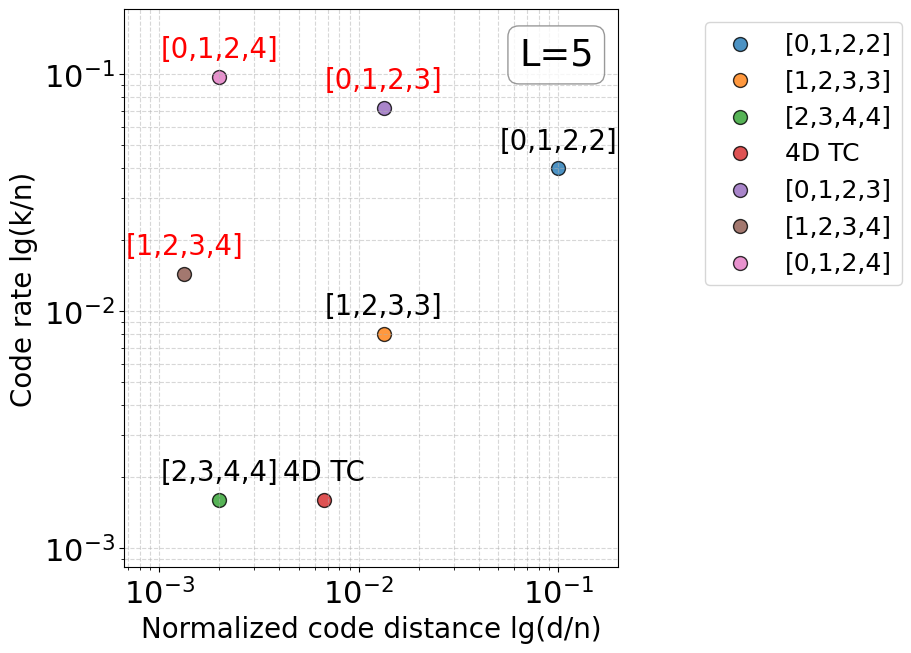

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_and_plot_codes(L_config, show_labels=False, font_size=12, log_scale=False):
    """
    Calculates code parameters and plots Code rate vs Normalized code distance.

    Parameters:
    -----------
    L_config : dict or int/float
        If int or float: The value L is applied to all codes.
        If dict: Keys must match code names, values are the L for that specific code.
    show_labels : bool
        If True, annotates each point on the plot with its code name.
    font_size : int
        Sets the global font size for the plot.
    log_scale : bool
        If True, sets both axes to logarithmic scale.
    """

    # Define the code parameters based on the provided table
    # Keys are the Names, Values are dictionaries of lambda functions for n, k_n (k/n), d_n (d/n)
    code_library = {
        "[0,1,2,2]": {
            "n":   lambda L: 2 * L**2,
            "k_n": lambda L: 1.0 / L**2,
            "d_n": lambda L: 1.0 / (2 * L)
        },
        "[1,2,3,3]": {
            "n":   lambda L: 3 * L**3,
            "k_n": lambda L: 1.0 / L**3,
            "d_n": lambda L: 1.0 / (3 * L**2)
        },
        "[2,3,4,4]": {
            "n":   lambda L: 4 * L**4,
            "k_n": lambda L: 1.0 / L**4,
            "d_n": lambda L: 1.0 / (4 * L**3)
        },
        "4D TC": {
            "n":   lambda L: 6 * L**4,
            "k_n": lambda L: 1.0 / L**4,
            "d_n": lambda L: 1.0 / (6 * L**2)
        },
        "[0,1,2,3]": {
            "n":   lambda L: 3 * L**3,
            "k_n": lambda L: (2 * L - 1) / L**3,
            "d_n": lambda L: 1.0 / (3 * L**2)
        },
        "[1,2,3,4]": {
            "n":   lambda L: 6 * L**4,
            "k_n": lambda L: (2 * L - 1) / L**4,
            "d_n": lambda L: 1.0 / (6 * L**3)
        },
        "[0,1,2,4]": {
            "n":   lambda L: 4 * L**4,
            "k_n": lambda L: (3 * L**2 - 3 * L + 1) / L**4,
            "d_n": lambda L: 1.0 / (4 * L**3)
        }
    }

    # Determine L values for each code
    active_codes = {}
    if isinstance(L_config, (int, float)):
        for name in code_library:
            active_codes[name] = float(L_config)
    elif isinstance(L_config, dict):
        for name, L_val in L_config.items():
            if name in code_library:
                active_codes[name] = float(L_val)
            else:
                print(f"Warning: Code '{name}' not found in library.")
    else:
        raise ValueError("L_config must be a number or a dictionary.")

    # Calculate results
    results = []
    print("-" * 80)
    print(f"{'Name':<20} | {'L':<5} | {'n':<12} | {'k/n':<12} | {'d/n':<12}")
    print("-" * 80)

    for name, L in active_codes.items():
        funcs = code_library[name]
        n_val = funcs["n"](L)
        k_n_val = funcs["k_n"](L)
        d_n_val = funcs["d_n"](L)
        
        results.append({
            "name": name,
            "L": L,
            "n": n_val,
            "k_n": k_n_val,
            "d_n": d_n_val
        })

        print(f"{name:<20} | {L:<5.1f} | {n_val:<12.1e} | {k_n_val:<12.4e} | {d_n_val:<12.4e}")
    print("-" * 80)

    # Plotting configuration
    plt.rcParams.update({'font.size': font_size})
    fig, ax = plt.subplots(figsize=(10, 7))

    # Identify which labels need to be colored red
    red_labels = ["[0,1,2,3]", "[0,1,2,4]", "[1,2,3,4]"]

    # Plot each point
    for res in results:
        ax.scatter(res["d_n"], res["k_n"], label=res["name"], s=100, alpha=0.8, edgecolors='k')
        
        if show_labels:
            # 1) Label specific points by red (text only, point color remains unchanged)
            text_color = 'red' if res["name"] in red_labels else 'black'
            
            ax.annotate(res["name"], (res["d_n"], res["k_n"]), 
            xytext=(0, 10), textcoords='offset points', 
            ha='center', va='bottom', fontsize=font_size * 0.9, color=text_color)

    # Axis scales
    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # Labels
    ax.set_xlabel("Normalized code distance lg(d/n)", fontsize=20)
    ax.set_ylabel("Code rate lg(k/n)", fontsize=20)
    
    # Grid and Legend
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=18)
    
    # 2) Put a caption "L=L_config" in the output figure (upper right side)
    caption_text = f"L={L_config}"
    # Transform is set to relative axis coordinates (0,0 is bottom-left, 1,1 is top-right)
    ax.text(0.95, 0.95, caption_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=font_size * 1.2, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

    def expand_axis(original_min, original_max, expansion_factor, is_log):
        if is_log:
            # Convert to log domain
            log_min = np.log10(original_min)
            log_max = np.log10(original_max)
            center = (log_max + log_min) / 2.0
            span = log_max - log_min
            # Expand span
            new_span = span * expansion_factor
            # Convert back to linear domain
            new_min = 10**(center - new_span / 2.0)
            new_max = 10**(center + new_span / 2.0)
            return new_min, new_max
        else:
            center = (original_max + original_min) / 2.0
            span = original_max - original_min
            new_span = span * expansion_factor
            return center - new_span / 2.0, center + new_span / 2.0
            
    # Get current limits determined by matplotlib based on data
    cur_xlim = ax.get_xlim()
    cur_ylim = ax.get_ylim()
    
    # Calculate new limits
    new_xlim = expand_axis(cur_xlim[0], cur_xlim[1], 1.2, log_scale)
    new_ylim = expand_axis(cur_ylim[0], cur_ylim[1], 1.2, log_scale)
    
    # Set new limits
    ax.set_xlim(new_xlim)
    ax.set_ylim(new_ylim)
    # -------------------------------------------------------------------------
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage
# ==========================================

if __name__ == "__main__":
    # Case 1: Unified L for all codes
    print("Running with unified L = 5:")
    analyze_and_plot_codes(L_config=5, show_labels=True, log_scale=True, font_size=22)

    # Case 2: Independent L values (Uncomment to test)
    # custom_L = {
    #     "[0,1,2,2]": 8,
    #     "[1,2,3,3]": 10,
    #     "4D TC": 12,
    #     "[0,1,2,4]": 20
    # }
    # print("\nRunning with custom L configuration:")
    # analyze_and_plot_codes(L_config=custom_L, show_labels=True, log_scale=True)

In [ ]:
e